In [1]:
import pandas as pd
import numpy as np

sale_df = pd.read_csv("../data/raw/sales.csv")
sale_df.head()

,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,425390,366,4,2013-04-18,517,1,0,0,0,4422
1,291687,394,6,2015-04-11,694,1,0,0,0,8297
2,411278,807,4,2013-08-29,970,1,1,0,0,9729
3,664714,802,2,2013-05-28,473,1,1,0,0,6513
4,540835,726,4,2013-10-10,1068,1,1,0,0,10882


In [2]:
sale_df.dtypes

Unnamed: 0              int64
store_ID                int64
day_of_week             int64
date                   object
nb_customers_on_day     int64
open                    int64
promotion               int64
state_holiday          object
school_holiday          int64
sales                   int64
dtype: object

In [3]:
sale_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 640840 entries, 0 to 640839
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   Unnamed: 0           640840 non-null  int64 
 1   store_ID             640840 non-null  int64 
 2   day_of_week          640840 non-null  int64 
 3   date                 640840 non-null  object
 4   nb_customers_on_day  640840 non-null  int64 
 5   open                 640840 non-null  int64 
 6   promotion            640840 non-null  int64 
 7   state_holiday        640840 non-null  object
 8   school_holiday       640840 non-null  int64 
 9   sales                640840 non-null  int64 
dtypes: int64(8), object(2)
memory usage: 48.9+ MB


In [4]:
sale_df.describe()

,Unnamed: 0,store_ID,day_of_week,nb_customers_on_day,open,promotion,school_holiday,sales
count,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000
mean,355990.675084,558.211348,4.000189,633.398577,0.830185,0.381718,0.178472,5777.469011
std,205536.290268,321.878521,1.996478,464.094416,0.375470,0.485808,0.382910,3851.338083
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,178075.750000,280.000000,2.000000,405.000000,1.000000,0.000000,0.000000,3731.000000
50%,355948.500000,558.000000,4.000000,609.000000,1.000000,0.000000,0.000000,5746.000000
75%,533959.250000,837.000000,6.000000,838.000000,1.000000,1.000000,0.000000,7860.000000
max,712044.000000,1115.000000,7.000000,5458.000000,1.000000,1.000000,1.000000,41551.000000


In [5]:
sale_df.isna().sum()

Unnamed: 0             0
store_ID               0
day_of_week            0
date                   0
nb_customers_on_day    0
open                   0
promotion              0
state_holiday          0
school_holiday         0
sales                  0
dtype: int64

In [6]:
sale_df.nunique()

Unnamed: 0             640840
store_ID                 1115
day_of_week                 7
date                      942
nb_customers_on_day      3886
open                        2
promotion                   2
state_holiday               4
school_holiday              2
sales                   20129
dtype: int64

In [7]:
sale_df["store_ID"]

0          366
1          394
2          807
3          802
4          726
          ... 
640835     409
640836      97
640837     987
640838    1084
640839     695
Name: store_ID, Length: 640840, dtype: int64

# we will remove unamed, date
# we change the format of state_holiday


In [8]:
sale_df["state_holiday"].value_counts()


state_holiday
0    621160
a     12842
b      4214
c      2624
Name: count, dtype: int64

In [9]:
# Which columns contain the features of the websites?
#X = sale_df.drop(columns=['URL', 'Type'])
#y = websites['Type']
#display(X)

sale_df = pd.get_dummies(sale_df, columns=['state_holiday'])

In [10]:
sale_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 640840 entries, 0 to 640839
Data columns (total 13 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   Unnamed: 0           640840 non-null  int64 
 1   store_ID             640840 non-null  int64 
 2   day_of_week          640840 non-null  int64 
 3   date                 640840 non-null  object
 4   nb_customers_on_day  640840 non-null  int64 
 5   open                 640840 non-null  int64 
 6   promotion            640840 non-null  int64 
 7   school_holiday       640840 non-null  int64 
 8   sales                640840 non-null  int64 
 9   state_holiday_0      640840 non-null  bool  
 10  state_holiday_a      640840 non-null  bool  
 11  state_holiday_b      640840 non-null  bool  
 12  state_holiday_c      640840 non-null  bool  
dtypes: bool(4), int64(8), object(1)
memory usage: 46.4+ MB


In [11]:
X = sale_df.drop(columns=["Unnamed: 0", "sales","state_holiday_0","date"])
y = sale_df["sales"]
display(X)


,store_ID,day_of_week,nb_customers_on_day,open,promotion,school_holiday,state_holiday_a,state_holiday_b,state_holiday_c
0,366,4,517,1,0,0,False,False,False
1,394,6,694,1,0,0,False,False,False
2,807,4,970,1,1,0,False,False,False
3,802,2,473,1,1,0,False,False,False
4,726,4,1068,1,1,0,False,False,False
...,...,...,...,...,...,...,...,...,...
640835,409,6,483,1,0,0,False,False,False
640836,97,1,987,1,1,0,False,False,False
640837,987,1,925,1,0,0,False,False,False
640838,1084,4,725,1,0,0,False,False,False


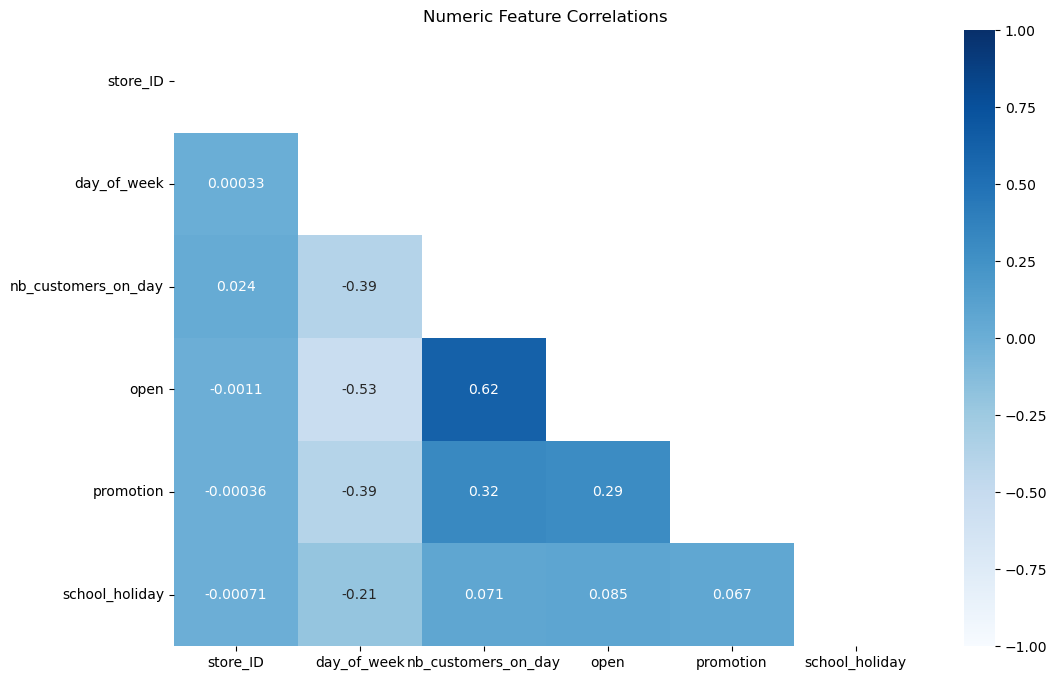

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
#plt.figure(figsize=(12, 10))
#sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
#plt.show()


features = X.select_dtypes(include="number")
mask = np.triu(np.ones_like(features.corr(), dtype=bool)) 
corr = features.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True,cmap="Blues", vmin=-1, vmax=1,mask=mask)
plt.title("Numeric Feature Correlations")
plt.show()

In [13]:
X = X.drop(columns=["open"])
display(X)

,store_ID,day_of_week,nb_customers_on_day,promotion,school_holiday,state_holiday_a,state_holiday_b,state_holiday_c
0,366,4,517,0,0,False,False,False
1,394,6,694,0,0,False,False,False
2,807,4,970,1,0,False,False,False
3,802,2,473,1,0,False,False,False
4,726,4,1068,1,0,False,False,False
...,...,...,...,...,...,...,...,...
640835,409,6,483,0,0,False,False,False
640836,97,1,987,1,0,False,False,False
640837,987,1,925,0,0,False,False,False
640838,1084,4,725,0,0,False,False,False


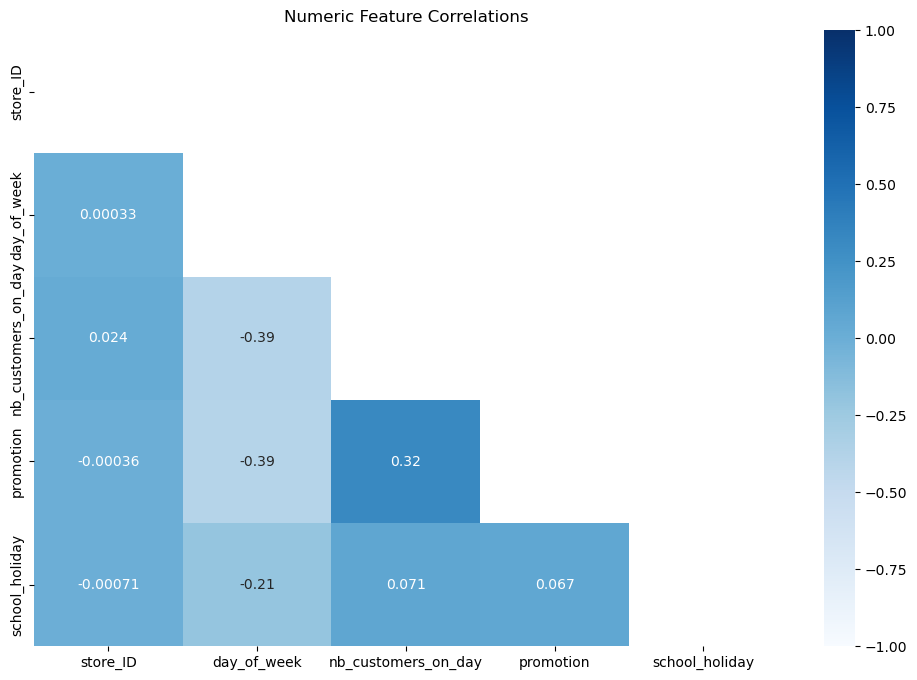

In [14]:
features = X.select_dtypes(include="number")
mask = np.triu(np.ones_like(features.corr(), dtype=bool)) 
corr = features.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True,cmap="Blues", vmin=-1, vmax=1,mask=mask)
plt.title("Numeric Feature Correlations")
plt.show()

### we dropped open feature because it has strong correlation with the day_of_week and nb_customers_on_day
data doesn't have any empty samples in it

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
print("Train:", X_train.shape) 
print("Validation:", X_val.shape) 
print("Test:", X_test.shape)

Train: (448588, 8)
Validation: (96126, 8)
Test: (96126, 8)


In [16]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 640840 entries, 0 to 640839
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   store_ID             640840 non-null  int64
 1   day_of_week          640840 non-null  int64
 2   nb_customers_on_day  640840 non-null  int64
 3   promotion            640840 non-null  int64
 4   school_holiday       640840 non-null  int64
 5   state_holiday_a      640840 non-null  bool 
 6   state_holiday_b      640840 non-null  bool 
 7   state_holiday_c      640840 non-null  bool 
dtypes: bool(3), int64(5)
memory usage: 26.3 MB


In [17]:
X.describe()

,store_ID,day_of_week,nb_customers_on_day,promotion,school_holiday
count,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000
mean,558.211348,4.000189,633.398577,0.381718,0.178472
std,321.878521,1.996478,464.094416,0.485808,0.382910
min,1.000000,1.000000,0.000000,0.000000,0.000000
25%,280.000000,2.000000,405.000000,0.000000,0.000000
50%,558.000000,4.000000,609.000000,0.000000,0.000000
75%,837.000000,6.000000,838.000000,1.000000,0.000000
max,1115.000000,7.000000,5458.000000,1.000000,1.000000


In [26]:
#from sklearn.linear_model import LinearRegression 
#model = LinearRegression() 
#model.fit(X_train, y_train) 
#predictions = model.predict(X_test)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(np.min(X_train_scaled))
print(np.max(X_train_scaled))


-1.728899938442448
15.552294026466077


In [31]:


print("Means:")
print(X_train_scaled.mean(axis=0))

print("Standard deviations:")
print(X_train_scaled.std(axis=0))

scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

print(scaler.mean_)
print(scaler.scale_)



Means:
[ 5.62620444e-17 -9.72547727e-17  5.83211845e-17  1.35586458e-17
  2.20486390e-17  6.05703992e-17 -1.41922274e-17 -1.03907379e-17]
Standard deviations:
[1. 1. 1. 1. 1. 1. 1. 1.]
[5.57609461e+02 4.00158943e+00 6.33217812e+02 3.81737808e-01
 1.78159023e-01 1.99492630e-02 6.58733626e-03 4.11736382e-03]
[3.21944289e+02 1.99744473e+00 4.64450856e+02 4.85812777e-01
 3.82646555e-01 1.39825927e-01 8.08946430e-02 6.40344527e-02]


In [29]:
scaled_df.head()

,store_ID,day_of_week,nb_customers_on_day,promotion,school_holiday,state_holiday_a,state_holiday_b,state_holiday_c
439297,0.569634,-1.002075,0.053358,-0.785771,-0.465597,-0.142672,-0.081431,-0.064299
326963,1.020023,1.000484,-0.215777,-0.785771,-0.465597,-0.142672,-0.081431,-0.064299
348005,-1.676096,-0.000796,0.036133,-0.785771,-0.465597,-0.142672,-0.081431,-0.064299
270031,0.259022,-1.502715,0.260054,1.272635,-0.465597,-0.142672,-0.081431,-0.064299
106547,-1.620185,1.000484,0.929662,-0.785771,-0.465597,-0.142672,-0.081431,-0.064299


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

predictions = model.predict(X_test_scaled)



In [33]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

MAE:  1064.87
MSE:  2329770.55
RMSE: 1526.36
R²:   0.8423


In [34]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

display(results.head(10))

,Actual,Predicted
586068,0,-634.181885
450188,11407,11099.440279
444261,8919,7739.939234
25114,4801,5365.955420
306712,5883,6006.840496
436526,0,663.401958
87355,6547,7048.508885
482130,4214,4913.621128
242746,7494,6931.188546
33669,0,633.971012


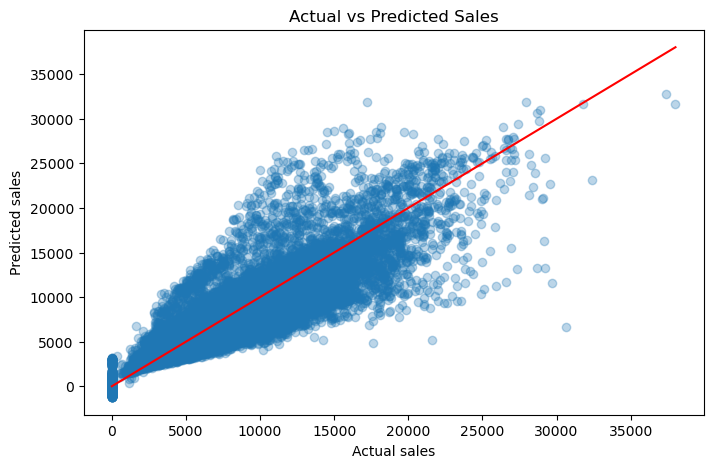

In [35]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, predictions, alpha=0.3)
plt.xlabel("Actual sales")
plt.ylabel("Predicted sales")
plt.title("Actual vs Predicted Sales")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.show()

In [36]:
val_predictions = model.predict(X_val_scaled)

val_mae = mean_absolute_error(y_val, val_predictions)
val_rmse = np.sqrt(mean_squared_error(y_val, val_predictions))
val_r2 = r2_score(y_val, val_predictions)

print(f"Validation MAE:  {val_mae:.2f}")
print(f"Validation RMSE: {val_rmse:.2f}")
print(f"Validation R²:   {val_r2:.4f}")

Validation MAE:  1066.49
Validation RMSE: 1527.61
Validation R²:   0.8427


In [37]:
test_predictions = model.predict(X_test_scaled)

print(f"Test MAE:  {mean_absolute_error(y_test, test_predictions):.2f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, test_predictions)):.2f}")
print(f"Test R²:   {r2_score(y_test, test_predictions):.4f}")

Test MAE:  1064.87
Test RMSE: 1526.36
Test R²:   0.8423
